# Track B - Predicting the future of the swaption market

## Loading and processing data

In [133]:
from datasets import load_dataset

ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)
print(ds_level1)

Dataset({
    features: ['Date', 'Tenor : 1; Maturity : 0.0833333333333333', 'Tenor : 2; Maturity : 0.0833333333333333', 'Tenor : 3; Maturity : 0.0833333333333333', 'Tenor : 4; Maturity : 0.0833333333333333', 'Tenor : 5; Maturity : 0.0833333333333333', 'Tenor : 6; Maturity : 0.0833333333333333', 'Tenor : 7; Maturity : 0.0833333333333333', 'Tenor : 8; Maturity : 0.0833333333333333', 'Tenor : 9; Maturity : 0.0833333333333333', 'Tenor : 10; Maturity : 0.0833333333333333', 'Tenor : 15; Maturity : 0.0833333333333333', 'Tenor : 20; Maturity : 0.0833333333333333', 'Tenor : 25; Maturity : 0.0833333333333333', 'Tenor : 30; Maturity : 0.0833333333333333', 'Tenor : 1; Maturity : 0.25', 'Tenor : 2; Maturity : 0.25', 'Tenor : 3; Maturity : 0.25', 'Tenor : 4; Maturity : 0.25', 'Tenor : 5; Maturity : 0.25', 'Tenor : 6; Maturity : 0.25', 'Tenor : 7; Maturity : 0.25', 'Tenor : 8; Maturity : 0.25', 'Tenor : 9; Maturity : 0.25', 'Tenor : 10; Maturity : 0.25', 'Tenor : 15; Maturity : 0.25', 'Tenor : 20; M

In [134]:
import pandas as pd

df_level1 = pd.DataFrame(ds_level1)
df_level1.head()

,Date,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,01/01/2050,0.028565,0.038700,0.040127,0.040762,0.040466,0.038953,0.037553,0.036768,0.036646,...,0.331053,0.329056,0.330997,0.324676,0.325758,0.322393,0.345859,0.359162,0.346670,0.337670
1,02/01/2050,0.029334,0.039499,0.040982,0.041638,0.041336,0.039815,0.038397,0.037631,0.037504,...,0.336319,0.334434,0.336568,0.330244,0.331462,0.328144,0.351816,0.365197,0.350993,0.340822
2,03/01/2050,0.028696,0.038816,0.040328,0.041042,0.040804,0.039329,0.037968,0.037216,0.037107,...,0.333634,0.331707,0.333800,0.327487,0.328710,0.325436,0.348915,0.362236,0.348652,0.339027
3,05/01/2050,0.030854,0.041536,0.043035,0.043605,0.043241,0.041556,0.039977,0.039167,0.038968,...,0.336884,0.335106,0.337548,0.331279,0.332811,0.329771,0.353246,0.366100,0.351404,0.340465
4,06/01/2050,0.030406,0.041174,0.042681,0.043266,0.042937,0.041253,0.039685,0.038867,0.038667,...,0.333249,0.331426,0.333830,0.327580,0.329123,0.326146,0.349390,0.362048,0.348331,0.338022


In [135]:
df_level1.columns

Index(['Date', 'Tenor : 1; Maturity : 0.0833333333333333',
       'Tenor : 2; Maturity : 0.0833333333333333',
       'Tenor : 3; Maturity : 0.0833333333333333',
       'Tenor : 4; Maturity : 0.0833333333333333',
       'Tenor : 5; Maturity : 0.0833333333333333',
       'Tenor : 6; Maturity : 0.0833333333333333',
       'Tenor : 7; Maturity : 0.0833333333333333',
       'Tenor : 8; Maturity : 0.0833333333333333',
       'Tenor : 9; Maturity : 0.0833333333333333',
       ...
       'Tenor : 5; Maturity : 30', 'Tenor : 6; Maturity : 30',
       'Tenor : 7; Maturity : 30', 'Tenor : 8; Maturity : 30',
       'Tenor : 9; Maturity : 30', 'Tenor : 10; Maturity : 30',
       'Tenor : 15; Maturity : 30', 'Tenor : 20; Maturity : 30',
       'Tenor : 25; Maturity : 30', 'Tenor : 30; Maturity : 30'],
      dtype='object', length=225)

In [136]:
len(df_level1.columns)

225

In [137]:
# Check the missing values in the dataset
missing_values = df_level1.isnull().sum()
print("Missing values in each column:")

Missing values in each column:


In [138]:
# Convert Date column to datetime with correct format
df_level1['Date'] = pd.to_datetime(df_level1['Date'], dayfirst=True)

# Sort by date to ensure chronological order
df_level1_sorted = df_level1.sort_values('Date')

# Get the min and max dates
min_date = df_level1_sorted['Date'].min()
max_date = df_level1_sorted['Date'].max()

# Create a complete date range
complete_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Find missing dates
existing_dates = set(df_level1_sorted['Date'].dt.date)
complete_dates = set(complete_date_range.date)
missing_dates_df1 = sorted(complete_dates - existing_dates)

print(f"Total missing dates: {len(missing_dates_df1)}")
print(missing_dates_df1)

Total missing dates: 228
[datetime.date(2050, 1, 4), datetime.date(2050, 1, 7), datetime.date(2050, 1, 10), datetime.date(2050, 1, 13), datetime.date(2050, 1, 16), datetime.date(2050, 1, 19), datetime.date(2050, 1, 23), datetime.date(2050, 1, 26), datetime.date(2050, 1, 29), datetime.date(2050, 2, 1), datetime.date(2050, 2, 4), datetime.date(2050, 2, 7), datetime.date(2050, 2, 11), datetime.date(2050, 2, 14), datetime.date(2050, 2, 17), datetime.date(2050, 2, 20), datetime.date(2050, 2, 23), datetime.date(2050, 2, 26), datetime.date(2050, 3, 2), datetime.date(2050, 3, 5), datetime.date(2050, 3, 8), datetime.date(2050, 3, 11), datetime.date(2050, 3, 14), datetime.date(2050, 3, 17), datetime.date(2050, 3, 21), datetime.date(2050, 3, 24), datetime.date(2050, 3, 27), datetime.date(2050, 3, 30), datetime.date(2050, 4, 2), datetime.date(2050, 4, 5), datetime.date(2050, 4, 8), datetime.date(2050, 4, 12), datetime.date(2050, 4, 15), datetime.date(2050, 4, 18), datetime.date(2050, 4, 21), datet

In [139]:
print(df_level1.dtypes)

Date                                        datetime64[ns]
Tenor : 1; Maturity : 0.0833333333333333           float64
Tenor : 2; Maturity : 0.0833333333333333           float64
Tenor : 3; Maturity : 0.0833333333333333           float64
Tenor : 4; Maturity : 0.0833333333333333           float64
                                                 ...      
Tenor : 10; Maturity : 30                          float64
Tenor : 15; Maturity : 30                          float64
Tenor : 20; Maturity : 30                          float64
Tenor : 25; Maturity : 30                          float64
Tenor : 30; Maturity : 30                          float64
Length: 225, dtype: object


## Reduce dimensionality of data

In [140]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Sort by time (important for finance time series)
df = df_level1.sort_values("Date").reset_index(drop=True)

# 2) Select numeric features (drop Date)
X = df.drop(columns=["Date"])

# Optional safety: ensure all remaining are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 4) PCA pipeline: scale -> PCA(60)
pca_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", PCA(n_components=3, random_state=0))
])

# 5) Fit + transform
Z = pca_pipe.fit_transform(X)  # shape: (n_samples, 60)

# 6) Put into a DataFrame
Z_df = pd.DataFrame(Z, columns=[f"PC{i+1:02d}" for i in range(Z.shape[1])])
Z_df.insert(0, "Date", df["Date"].values)

print("Original shape:", X.shape)
print("Reduced shape:", Z_df.shape)

# 7) Explained variance (how much of the surface you keep)
explained = pca_pipe.named_steps["pca"].explained_variance_ratio_
print("Explained variance (sum):", explained.sum())
print("First 10 PCs:", explained[:10])

Original shape: (494, 224)
Reduced shape: (494, 4)
Explained variance (sum): 0.9992923794240122
First 10 PCs: [0.77477591 0.15479187 0.0697246 ]


## Train a basic Linear Regression to test

In [141]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = Z_df.sort_values("Date").reset_index(drop=True)

# Build supervised dataset (predict next day PCs)
pc_cols = [col for col in df.columns if col.startswith('PC')]
X = df[pc_cols].iloc[:-1].values
y = df[pc_cols].iloc[1:].values

# Train/test split (chronological!)
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [142]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Make sure raw data is sorted and preprocessed consistently
df_raw_sorted = df_level1.sort_values("Date").reset_index(drop=True)
yield_cols = [c for c in df_raw_sorted.columns if c != "Date"]

Y = df_raw_sorted[["Date"] + yield_cols].copy()
Y[yield_cols] = Y[yield_cols].apply(pd.to_numeric, errors="coerce")
Y[yield_cols] = Y[yield_cols].ffill().bfill()

# Recreate the test Dates exactly (these are the dates for y_test = t+1)
test_dates = df["Date"].iloc[split+1 : split+1 + len(y_pred)].reset_index(drop=True)

# Inverse PCA: predicted PCs -> predicted yields
n_test = len(y_pred)
n_components_fit = pca_pipe.named_steps["pca"].n_components_

Z_pred_full = np.zeros((n_test, n_components_fit), dtype=float)
Z_pred_full[:, :y_pred.shape[1]] = y_pred  # PC01-03

Y_pred_scaled = pca_pipe.named_steps["pca"].inverse_transform(Z_pred_full)
Y_pred = pca_pipe.named_steps["scaler"].inverse_transform(Y_pred_scaled)  # shape (n_test, n_yields)

# Get true yields for those same Dates (merge on Date)
Y_true = (
    Y.merge(test_dates.to_frame(name="Date"), on="Date", how="inner")
     .sort_values("Date")
     .reset_index(drop=True)
)

# Safety check: enforce same length by trimming to common min
n_common = min(len(Y_true), Y_pred.shape[0])
Y_true_vals = Y_true[yield_cols].iloc[:n_common].to_numpy()
Y_pred_vals = Y_pred[:n_common, :]

print("Pred rows:", Y_pred_vals.shape[0])
print("True rows:", Y_true_vals.shape[0])

# Yield-space MSE/RMSE
mse_yields = mean_squared_error(Y_true_vals, Y_pred_vals)
rmse_yields = np.sqrt(mse_yields)
print("Yield-space MSE:", mse_yields)
print("Yield-space RMSE:", rmse_yields)

Pred rows: 99
True rows: 99
Yield-space MSE: 1.3135701249839706e-05
Yield-space RMSE: 0.00362432079841723


In [143]:
first_col = yield_cols[50]  # first yield column name

print(f"\nColumn inspected: {first_col}\n")

for i in range(5):  # print first 5 test points (change if needed)
    print(f"Date: {test_dates.iloc[i].date()}")
    print(f"  Predicted (day X):      {Y_pred_vals[i, 0]:.6f}")
    print(f"  Actual (day X):         {Y_true_vals[i, 0]:.6f}")
    print()


Column inspected: Tenor : 9; Maturity : 0.75

Date: 2051-08-01
  Predicted (day X):      0.023474
  Actual (day X):         0.023354

Date: 2051-08-03
  Predicted (day X):      0.022455
  Actual (day X):         0.022681

Date: 2051-08-04
  Predicted (day X):      0.021472
  Actual (day X):         0.023603

Date: 2051-08-06
  Predicted (day X):      0.022839
  Actual (day X):         0.021903

Date: 2051-08-07
  Predicted (day X):      0.020187
  Actual (day X):         0.021551



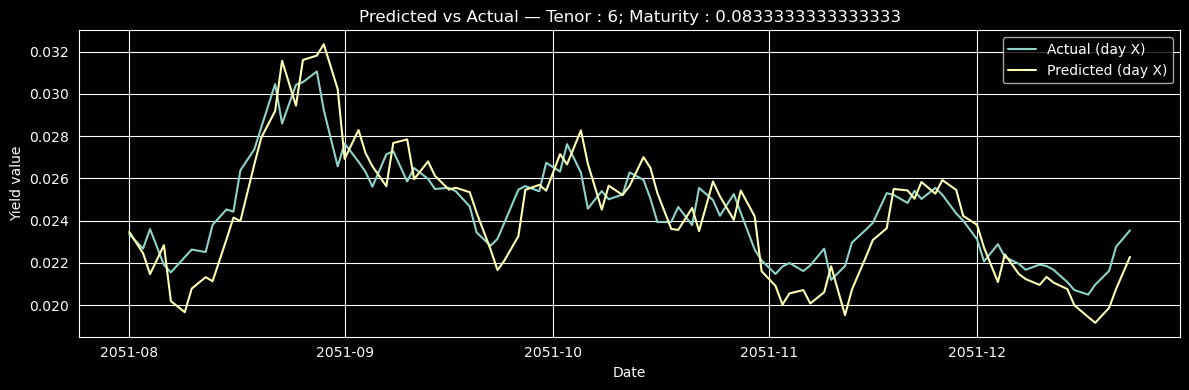

In [144]:
import matplotlib.pyplot as plt

# Plot predicted vs actual for the FIRST yield column over the test window
first_col = yield_cols[5]

dates_plot = test_dates.iloc[:len(Y_true_vals)]  # aligned
y_true_1 = Y_true_vals[:, 0]
y_pred_1 = Y_pred_vals[:, 0]

plt.figure(figsize=(12, 4))
plt.plot(dates_plot, y_true_1, label="Actual (day X)")
plt.plot(dates_plot, y_pred_1, label="Predicted (day X)")
plt.title(f"Predicted vs Actual — {first_col}")
plt.xlabel("Date")
plt.ylabel("Yield value")
plt.legend()
plt.tight_layout()
plt.show()

## Train a classical MLP

In [145]:
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset

# Hyperparameters
n_pcs = len(pc_cols)
hidden_dim = 1024
lr = 1e-3
epochs = 200
batch_size = 64

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=False)

# MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

model_mlp = MLP(input_dim=n_pcs, hidden_dim=hidden_dim, output_dim=n_pcs)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=lr)
criterion = nn.MSELoss()

# Training loop
model_mlp.train()
for epoch in tqdm(range(epochs)):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_mlp(xb), yb)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {loss.item():.6f}")

# Predict on test set
model_mlp.eval()
with torch.no_grad():
    y_pred_mlp = model_mlp(X_test_t).numpy()

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
print(f"\nPC-space MSE (MLP): {mse_mlp:.6f}")

 11%|█         | 22/200 [00:00<00:05, 31.90it/s]

Epoch 20/200 — Loss: 2.310650


 23%|██▎       | 46/200 [00:01<00:04, 32.62it/s]

Epoch 40/200 — Loss: 1.427480


 33%|███▎      | 66/200 [00:02<00:04, 33.36it/s]

...

Epoch 160/200 — Loss: 1.556743


 93%|█████████▎| 186/200 [00:06<00:00, 28.66it/s]

Epoch 180/200 — Loss: 1.187664


100%|██████████| 200/200 [00:06<00:00, 28.78it/s]

Epoch 200/200 — Loss: 1.531168

PC-space MSE (MLP): 3.583518


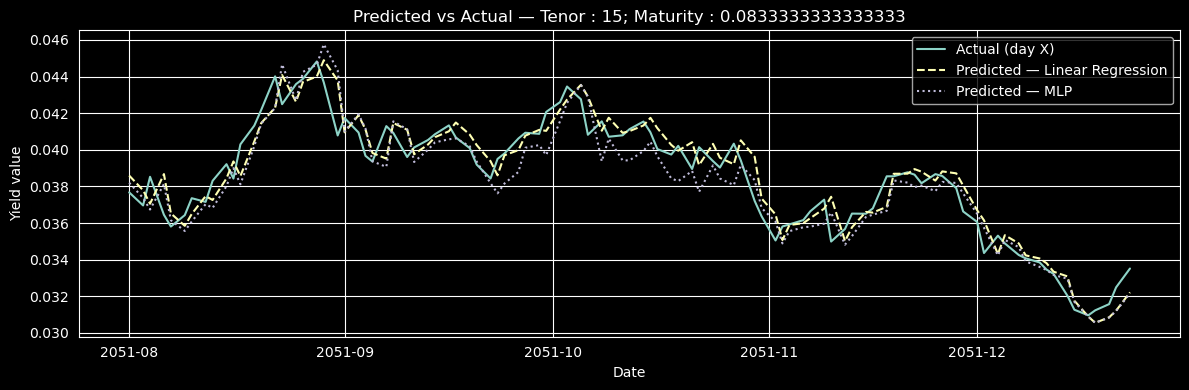

In [146]:
import matplotlib.pyplot as plt

# Inverse transform MLP predictions to yield space
Z_pred_mlp_full = np.zeros((len(y_pred_mlp), n_components_fit), dtype=float)
Z_pred_mlp_full[:, :y_pred_mlp.shape[1]] = y_pred_mlp

Y_pred_mlp_scaled = pca_pipe.named_steps["pca"].inverse_transform(Z_pred_mlp_full)
Y_pred_mlp = pca_pipe.named_steps["scaler"].inverse_transform(Y_pred_mlp_scaled)

# Align lengths
n_common_mlp = min(len(Y_true_vals), Y_pred_mlp.shape[0])
Y_pred_mlp_vals = Y_pred_mlp[:n_common_mlp, :]

# Plot predicted vs actual for yield column
col_idx = 10
first_col = yield_cols[col_idx]

dates_plot = test_dates.iloc[:n_common_mlp]
y_true_1     = Y_true_vals[:n_common_mlp, col_idx]  # True yields
y_pred_lr_1  = Y_pred_vals[:n_common_mlp, col_idx]   # Linear Regression
y_pred_mlp_1 = Y_pred_mlp_vals[:, col_idx]           # MLP

plt.figure(figsize=(12, 4))
plt.plot(dates_plot, y_true_1,     label="Actual (day X)")
plt.plot(dates_plot, y_pred_lr_1,  label="Predicted — Linear Regression", linestyle="--")
plt.plot(dates_plot, y_pred_mlp_1, label="Predicted — MLP",               linestyle=":")
plt.title(f"Predicted vs Actual — {first_col}")
plt.xlabel("Date")
plt.ylabel("Yield value")
plt.legend()
plt.tight_layout()
plt.show()

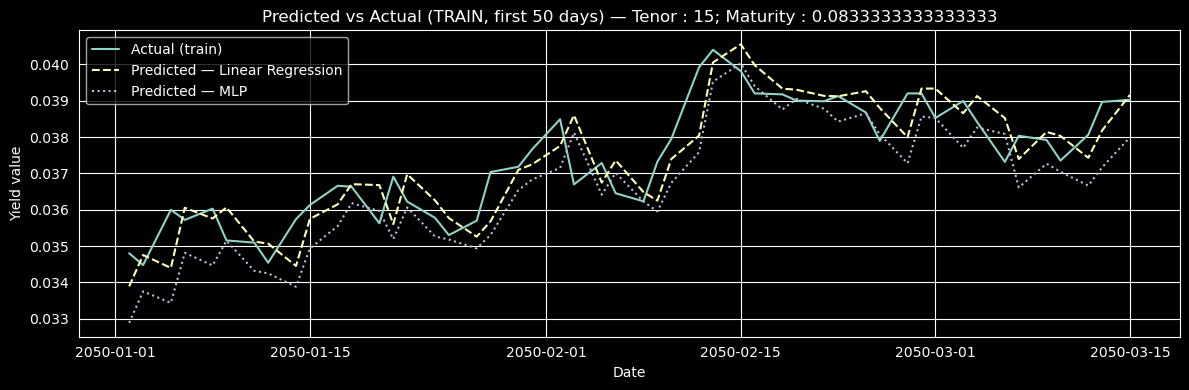

In [147]:
import matplotlib.pyplot as plt

# Inverse transform train predictions (Linear Regression)
y_pred_train_lr = model.predict(X_train)

Z_pred_train_lr_full = np.zeros((len(y_pred_train_lr), n_components_fit), dtype=float)
Z_pred_train_lr_full[:, :y_pred_train_lr.shape[1]] = y_pred_train_lr
Y_pred_train_lr_scaled = pca_pipe.named_steps["pca"].inverse_transform(Z_pred_train_lr_full)
Y_pred_train_lr = pca_pipe.named_steps["scaler"].inverse_transform(Y_pred_train_lr_scaled)

# Inverse transform train predictions (MLP)
model_mlp.eval()
with torch.no_grad():
    y_pred_train_mlp = model_mlp(X_train_t).numpy()

Z_pred_train_mlp_full = np.zeros((len(y_pred_train_mlp), n_components_fit), dtype=float)
Z_pred_train_mlp_full[:, :y_pred_train_mlp.shape[1]] = y_pred_train_mlp
Y_pred_train_mlp_scaled = pca_pipe.named_steps["pca"].inverse_transform(Z_pred_train_mlp_full)
Y_pred_train_mlp = pca_pipe.named_steps["scaler"].inverse_transform(Y_pred_train_mlp_scaled)

# Get true train yields
train_dates = df["Date"].iloc[1:split+1].reset_index(drop=True)
Y_true_train = (
    Y.merge(train_dates.to_frame(name="Date"), on="Date", how="inner")
     .sort_values("Date")
     .reset_index(drop=True)
)

n_common_train = min(len(Y_true_train), Y_pred_train_lr.shape[0], Y_pred_train_mlp.shape[0])
Y_true_train_vals    = Y_true_train[yield_cols].iloc[:n_common_train].to_numpy()
Y_pred_train_lr_vals  = Y_pred_train_lr[:n_common_train, :]
Y_pred_train_mlp_vals = Y_pred_train_mlp[:n_common_train, :]

# Number of dates to show and column to show
n_plot = 50
col_idx = 10
first_col = yield_cols[col_idx]

plt.figure(figsize=(12, 4))
plt.plot(train_dates[:n_plot], Y_true_train_vals[:n_plot, col_idx],      label="Actual (train)")
plt.plot(train_dates[:n_plot], Y_pred_train_lr_vals[:n_plot, col_idx],   label="Predicted — Linear Regression", linestyle="--")
plt.plot(train_dates[:n_plot], Y_pred_train_mlp_vals[:n_plot, col_idx],  label="Predicted — MLP",               linestyle=":")
plt.title(f"Predicted vs Actual (TRAIN, first {n_plot} days) — {first_col}")
plt.xlabel("Date")
plt.ylabel("Yield value")
plt.legend()
plt.tight_layout()
plt.show()

## Train an hygrid classical-quantum model with MerLin

n_pcs=3 -> n_modes=6
Quantum model trainable params: 715


 11%|█         | 22/200 [00:01<00:12, 14.56it/s]

Epoch 20/200 — Loss: 0.006073


 21%|██        | 42/200 [00:02<00:10, 15.26it/s]

Epoch 40/200 — Loss: 0.003903


...

Epoch 160/200 — Loss: 0.002590


 91%|█████████ | 182/200 [00:13<00:01, 13.06it/s]

Epoch 180/200 — Loss: 0.002821


100%|██████████| 200/200 [00:14<00:00, 13.41it/s]


Epoch 200/200 — Loss: 0.002320


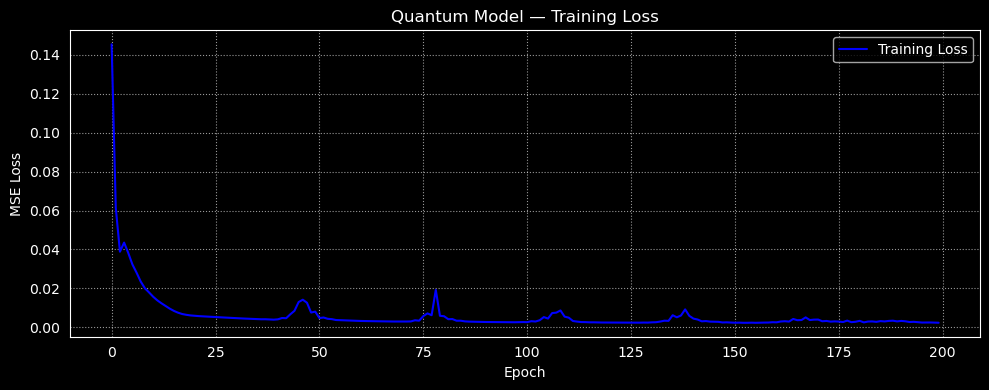


PC-space MSE (Quantum): 16.611958


In [148]:
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error
from merlin.builder import CircuitBuilder
from merlin import QuantumLayer, LexGrouping
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# =========================================================================
# 1. HIPERPARÂMETROS E CONFIGURAÇÕES INICIAIS
# =========================================================================
n_pcs = len(pc_cols)  # Número de componentes do PCA (input e output)
lr = 0.01
epochs = 200
batch_size = 64

# O MerLin exige no mínimo 4 modos. Se o PCA der 3, forçamos a 4.
n_modes = max(6, n_pcs)
print(f"n_pcs={n_pcs} -> n_modes={n_modes}")

# =========================================================================
# 2. A MAGIA DA FÍSICA: NORMALIZAR X (0 a Pi) e Y (0 a 1)
# =========================================================================
# Escalar os inputs (Mercado) para radianos (fase da luz)
scaler_x = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Escalar o Y (As 4 componentes do PCA alvo) para a rede "ver" o erro
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = scaler_y.fit_transform(y_train)

# Transformar para tensores do PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# Criar o DataLoader
train_loader_q = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=False)

# =========================================================================
# 3. CONSTRUIR O CHIP QUÂNTICO (DATA RE-UPLOADING)
# =========================================================================
def build_quantum_model(n_modes, output_dim, n_photons=2): 
    builder = CircuitBuilder(n_modes=n_modes)

    # ==========================================================
    # BLOCO 1: Superposição e PRIMEIRA INJEÇÃO DE DADOS
    # ==========================================================
    builder.add_entangling_layer(trainable=True, name="U1")
    builder.add_angle_encoding(modes=list(range(n_modes)), name="input_1")

    # ==========================================================
    # BLOCO 2: Mistura e SEGUNDA INJEÇÃO DE DADOS (Re-uploading)
    # ==========================================================
    builder.add_rotations(trainable=True, name="theta1")
    builder.add_entangling_layer(trainable=True, name="U2")
    builder.add_angle_encoding(modes=list(range(n_modes)), name="input_2")

    # ==========================================================
    # BLOCO 3: Afinação Final
    # ==========================================================
    builder.add_rotations(trainable=True, name="theta2")
    builder.add_superpositions(depth=1)

    quantum_core = QuantumLayer(
        input_size=n_modes * 2,
        builder=builder,
        n_photons=n_photons,
        dtype=torch.float32
    )

    model = nn.Sequential(
        quantum_core,
        LexGrouping(quantum_core.output_size, n_modes), 
        nn.Linear(n_modes, 64),
        nn.GELU(),
        nn.Linear(64, output_dim)
    )
    return model

# Iniciar o modelo com output_dim = n_pcs
model_quantum = build_quantum_model(n_modes=n_modes, output_dim=n_pcs)
optimizer_q = torch.optim.Adam(model_quantum.parameters(), lr=lr)
criterion_q = nn.MSELoss()

print(f"Quantum model trainable params: {sum(p.numel() for p in model_quantum.parameters()):,}")

# =========================================================================
# 4. CICLO DE TREINO (COM CLONAGEM DE DADOS)
# =========================================================================
losses = []  # Track loss per epoch

model_quantum.train()
for epoch in tqdm(range(epochs)):
    epoch_loss = 0.0
    for xb, yb in train_loader_q:
        if xb.shape[1] < n_modes:
            xb = torch.nn.functional.pad(xb, (0, n_modes - xb.shape[1]))
        xb_reuploaded = xb.repeat(1, 2)
        optimizer_q.zero_grad()
        loss = criterion_q(model_quantum(xb_reuploaded), yb)
        loss.backward()
        optimizer_q.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_q)
    losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}")

# Plot training loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(losses, label="Training Loss", color="blue")
plt.title("Quantum Model — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# =========================================================================
# 5. TESTAR E INVERTER A ESCALA PARA O GRÁFICO FINAL
# =========================================================================
model_quantum.eval()
with torch.no_grad():
    X_test_q = X_test_t
    if X_test_q.shape[1] < n_modes:
        X_test_q = torch.nn.functional.pad(X_test_q, (0, n_modes - X_test_q.shape[1]))
    
    # CLONAR OS DADOS NO TESTE TAMBÉM
    X_test_reuploaded = X_test_q.repeat(1, 2)
    
    # O modelo prevê as 4 componentes na escala (0 a 1)
    y_pred_scaled = model_quantum(X_test_reuploaded).numpy()

# Desfazemos a escala das 4 colunas de volta para a realidade do mercado
y_pred_quantum = scaler_y.inverse_transform(y_pred_scaled)

# Calculamos o erro comparando com o y_test ORIGINAL
mse_quantum = mean_squared_error(y_test, y_pred_quantum)
print(f"\nPC-space MSE (Quantum): {mse_quantum:.6f}")

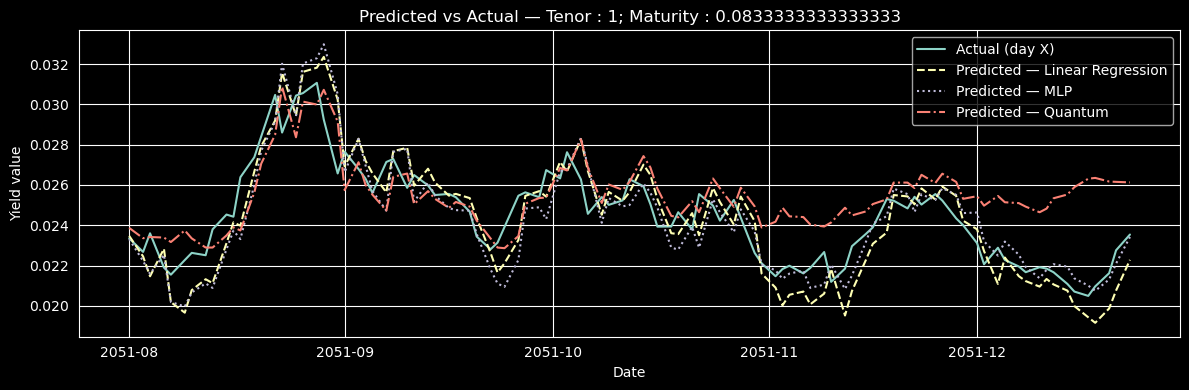

Yield-space MSE (Quantum): 0.000088


In [149]:
import matplotlib.pyplot as plt

# Inverse transform Quantum predictions to yield space
Z_pred_quantum_full = np.zeros((len(y_pred_quantum), n_components_fit), dtype=float)
Z_pred_quantum_full[:, :y_pred_quantum.shape[1]] = y_pred_quantum

Y_pred_quantum_scaled = pca_pipe.named_steps["pca"].inverse_transform(Z_pred_quantum_full)
Y_pred_quantum = pca_pipe.named_steps["scaler"].inverse_transform(Y_pred_quantum_scaled)

# Align lengths
n_common_q = min(len(Y_true_vals), Y_pred_quantum.shape[0], Y_pred_mlp.shape[0], Y_pred_vals.shape[0])
Y_pred_quantum_vals = Y_pred_quantum[:n_common_q, :]

for i in range(1):
    # Plot predicted vs actual for yield column
    col_idx = i
    first_col = yield_cols[col_idx]

    dates_plot = test_dates.iloc[:n_common_q]
    y_true_1        = Y_true_vals[:n_common_q, col_idx]   # True yields
    y_pred_lr_1     = Y_pred_vals[:n_common_q, col_idx]   # Linear Regression
    y_pred_mlp_1    = Y_pred_mlp_vals[:n_common_q, col_idx]  # MLP
    y_pred_quantum_1 = Y_pred_quantum_vals[:, col_idx]    # Quantum

    plt.figure(figsize=(12, 4))
    plt.plot(dates_plot, y_true_1,         label="Actual (day X)")
    plt.plot(dates_plot, y_pred_lr_1,      label="Predicted — Linear Regression", linestyle="--")
    plt.plot(dates_plot, y_pred_mlp_1,     label="Predicted — MLP",               linestyle=":")
    plt.plot(dates_plot, y_pred_quantum_1, label="Predicted — Quantum",            linestyle="-.")
    plt.title(f"Predicted vs Actual — {first_col}")
    plt.xlabel("Date")
    plt.ylabel("Yield value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    mse_quantum_yield = mean_squared_error(Y_true_vals[:n_common_q], Y_pred_quantum_vals)
    print(f"Yield-space MSE (Quantum): {mse_quantum_yield:.6f}")

🏆 GLOBAL MODEL SUMMARY (ALL COLUMNS) 🏆
-------------------------------------------------------
Global MAE  | Quantum: 0.005727 | Classical MLP: 0.003251
Global RMSE | Quantum: 0.009395 | Classical MLP: 0.004279
-------------------------------------------------------


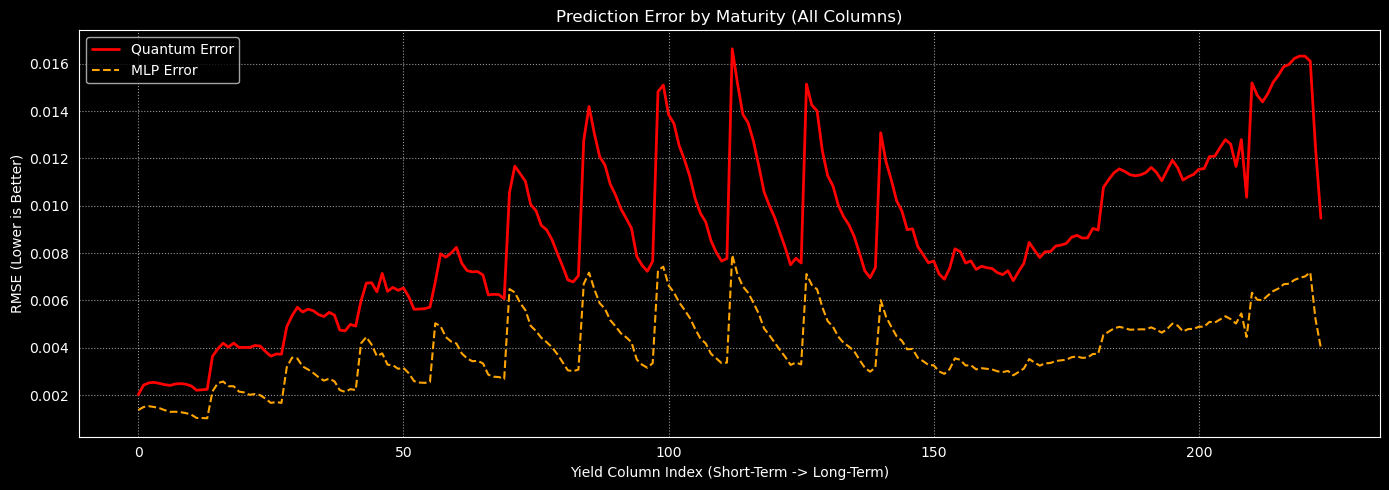

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ensure the arrays have the same length before comparing
# (Assuming Y_true_vals, Y_pred_quantum, and Y_pred_mlp_vals are already inverse-transformed to the original space)
n_common = min(len(Y_true_vals), Y_pred_quantum.shape[0], Y_pred_mlp_vals.shape[0])
y_true_global = Y_true_vals[:n_common]
y_pred_q_global = Y_pred_quantum[:n_common]
y_pred_mlp_global = Y_pred_mlp_vals[:n_common]

# =====================================================================
# 1. THE GOLDEN METRICS (Global Evaluation)
# =====================================================================
# Global MAE (Easy to interpret: "How many yield points are we off on average?")
mae_global_q = mean_absolute_error(y_true_global, y_pred_q_global)
mae_global_mlp = mean_absolute_error(y_true_global, y_pred_mlp_global)

# Global RMSE (Penalizes large errors and explosions)
rmse_global_q = np.sqrt(mean_squared_error(y_true_global, y_pred_q_global))
rmse_global_mlp = np.sqrt(mean_squared_error(y_true_global, y_pred_mlp_global))

print("🏆 GLOBAL MODEL SUMMARY (ALL COLUMNS) 🏆")
print("-" * 55)
print(f"Global MAE  | Quantum: {mae_global_q:.6f} | Classical MLP: {mae_global_mlp:.6f}")
print(f"Global RMSE | Quantum: {rmse_global_q:.6f} | Classical MLP: {rmse_global_mlp:.6f}")
print("-" * 55)

# =====================================================================
# 2. THE X-RAY (Error per Column / Maturity)
# =====================================================================
# Calculate RMSE only along the rows (axis=0), resulting in an error per column
rmse_per_column_q = np.sqrt(np.mean((y_true_global - y_pred_q_global)**2, axis=0))
rmse_per_column_mlp = np.sqrt(np.mean((y_true_global - y_pred_mlp_global)**2, axis=0))

# Create a line plot to compare where each model struggles
plt.figure(figsize=(14, 5))
columns_x = np.arange(len(rmse_per_column_q)) # X-axis (Column/Maturity Index)

plt.plot(columns_x, rmse_per_column_q, label="Quantum Error", color="red", linewidth=2)
plt.plot(columns_x, rmse_per_column_mlp, label="MLP Error", color="orange", linestyle="--")

plt.title("Prediction Error by Maturity (All Columns)")
plt.xlabel("Yield Column Index (Short-Term -> Long-Term)")
plt.ylabel("RMSE (Lower is Better)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [151]:
import pandas as pd

test_df = pd.read_excel("test.xlsx")
test_df.head()

,Date,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,24/12/2051,0.024065,0.032297,0.034346,0.036002,0.036554,0.035996,0.035624,0.035334,0.035619,...,0.348034,0.346277,0.348673,0.342354,0.343989,0.340939,0.364185,0.379464,0.358479,0.347285
1,26/12/2051,0.025887,0.034615,0.036713,0.038291,0.038729,0.038010,0.037453,0.037120,0.037336,...,0.353560,0.351967,0.354643,0.348353,0.350167,0.347196,0.370647,0.385485,0.363292,0.350501
2,27/12/2051,0.026653,0.035496,0.037586,0.039115,0.039484,0.038705,0.038077,0.037726,0.037919,...,0.356970,0.355439,0.358176,0.351889,0.353709,0.350698,0.374313,0.389137,0.366218,0.352714
3,29/12/2051,0.028115,0.037095,0.039163,0.040607,0.040846,0.039971,0.039227,0.038851,0.039010,...,0.364130,0.362719,0.365570,0.359298,0.361133,0.358052,0.381931,0.396786,0.372245,0.357328
4,30/12/2051,0.030511,0.039368,0.041405,0.042774,0.042825,0.041876,0.041040,0.040669,0.040816,...,0.380437,0.379270,0.382305,0.376105,0.377968,0.374758,0.398872,0.413961,0.385504,0.367756


Test MAE:  0.003259
Test RMSE: 0.004745


/home/yeray142/miniconda3/envs/dock_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  .. versionchanged:: 1.6


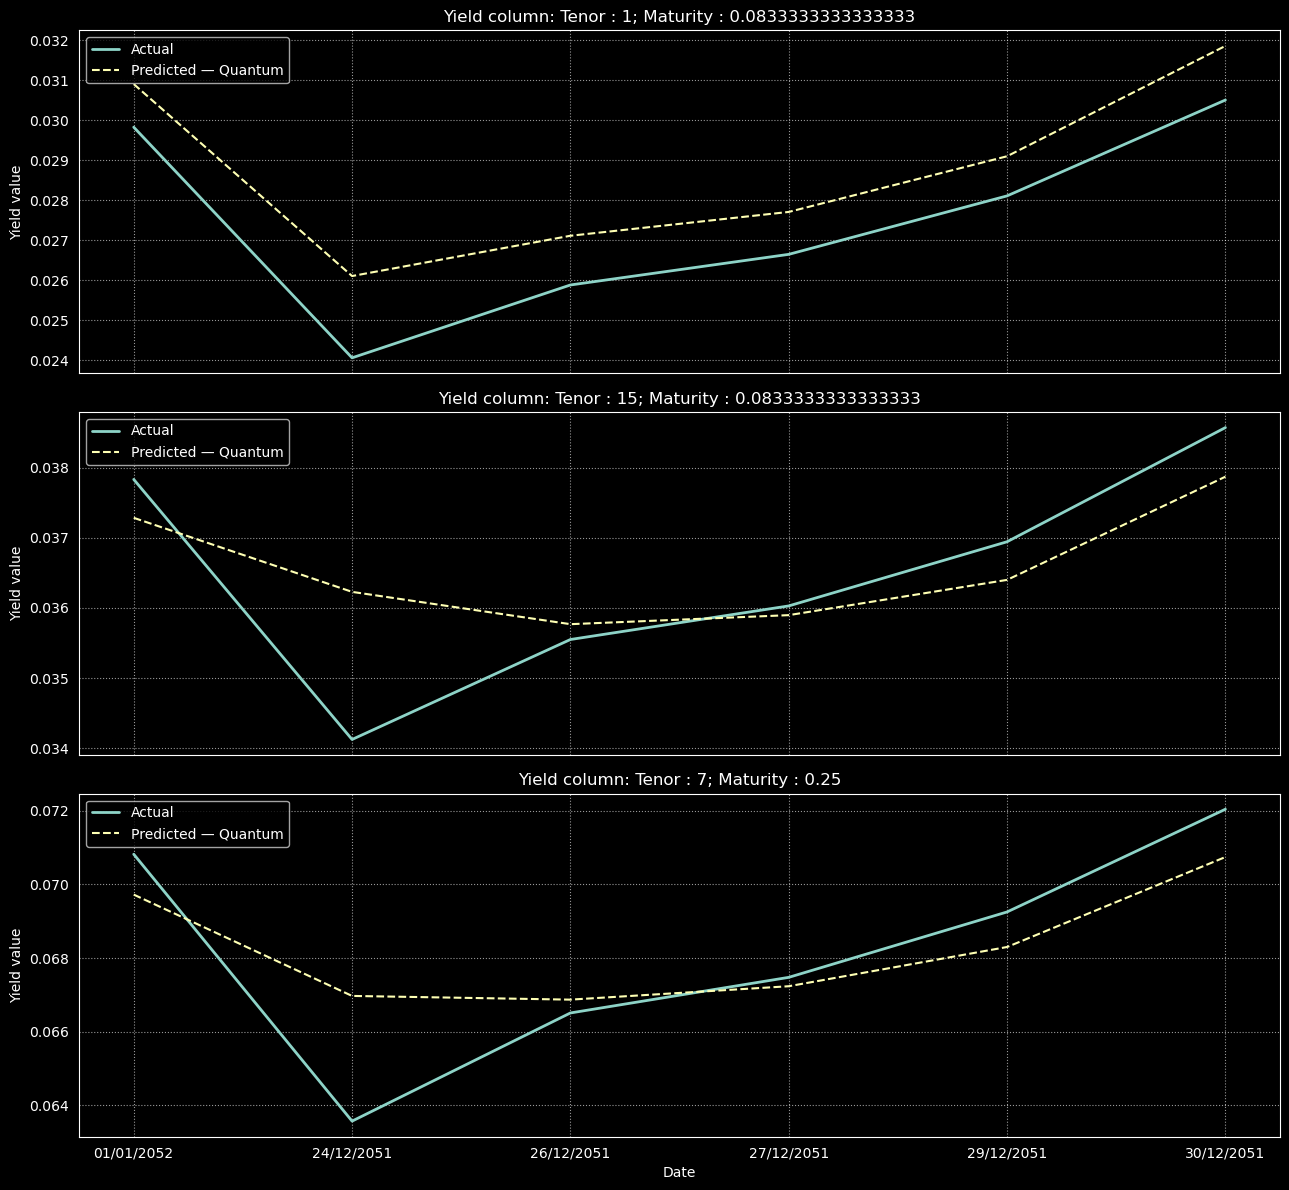

,Date,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,01/01/2052,0.030910,0.038906,0.040623,0.041768,0.041619,0.040626,0.039755,0.039324,0.039474,...,0.379543,0.378252,0.380929,0.374788,0.376357,0.372960,0.396602,0.411550,0.384595,0.367875
1,24/12/2051,0.026110,0.034356,0.036482,0.038155,0.038638,0.038066,0.037680,0.037461,0.037779,...,0.365732,0.364352,0.367246,0.361098,0.363127,0.360271,0.383172,0.397960,0.372315,0.357654
2,26/12/2051,0.027117,0.035506,0.037470,0.038896,0.039160,0.038381,0.037745,0.037396,0.037608,...,0.362428,0.360964,0.363663,0.357462,0.359234,0.356152,0.379440,0.394076,0.370205,0.356137
3,27/12/2051,0.027713,0.036093,0.038007,0.039366,0.039553,0.038717,0.038015,0.037637,0.037825,...,0.363707,0.362251,0.364925,0.358724,0.360444,0.357304,0.380678,0.395311,0.371380,0.357110
4,29/12/2051,0.029106,0.037419,0.039242,0.040483,0.040515,0.039577,0.038763,0.038341,0.038491,...,0.368306,0.366896,0.369559,0.363375,0.365025,0.361788,0.385289,0.399959,0.375333,0.360313


In [152]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare test data
test_df_sorted = test_df.sort_values("Date").reset_index(drop=True)
X_test_new = test_df_sorted.drop(columns=["Date"]).apply(pd.to_numeric, errors="coerce").values

# Apply same PCA pipeline + scale
Z_test_new = pca_pipe.transform(X_test_new)
X_test_new_scaled = scaler_x.transform(Z_test_new)
X_test_new_t = torch.tensor(X_test_new_scaled, dtype=torch.float32)

# Pad and re-upload
if X_test_new_t.shape[1] < n_modes:
    X_test_new_t = torch.nn.functional.pad(X_test_new_t, (0, n_modes - X_test_new_t.shape[1]))
X_test_new_reuploaded = X_test_new_t.repeat(1, 2)

# Predict
model_quantum.eval()
with torch.no_grad():
    y_pred_new_scaled = model_quantum(X_test_new_reuploaded).numpy()

# Inverse transform to yield space
y_pred_new_pcs = scaler_y.inverse_transform(y_pred_new_scaled)
Z_pred_new_full = np.zeros((len(y_pred_new_pcs), n_components_fit))
Z_pred_new_full[:, :y_pred_new_pcs.shape[1]] = y_pred_new_pcs
Y_pred_new = pca_pipe.named_steps["scaler"].inverse_transform(
    pca_pipe.named_steps["pca"].inverse_transform(Z_pred_new_full)
)

# Build results DataFrame
results_df = pd.DataFrame(Y_pred_new, columns=yield_cols)
results_df.insert(0, "Date", test_df_sorted["Date"].values)

# True values from test_df
Y_true_new = test_df_sorted[yield_cols].apply(pd.to_numeric, errors="coerce").values

# Metrics
mae  = mean_absolute_error(Y_true_new, Y_pred_new)
rmse = np.sqrt(mean_squared_error(Y_true_new, Y_pred_new))
print(f"Test MAE:  {mae:.6f}")
print(f"Test RMSE: {rmse:.6f}")

# Plot a few columns side by side
cols_to_plot = [0, 10, 20]
fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(13, 4 * len(cols_to_plot)), sharex=True)
for ax, col_idx in zip(axes, cols_to_plot):
    ax.plot(test_df_sorted["Date"], Y_true_new[:, col_idx], label="Actual",    linewidth=2)
    ax.plot(test_df_sorted["Date"], Y_pred_new[:, col_idx], label="Predicted — Quantum", linestyle="--")
    ax.set_title(f"Yield column: {yield_cols[col_idx]}")
    ax.set_ylabel("Yield value")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

results_df.head()

In [153]:
# Save quantum model predictions to CSV
results_df.to_csv("quantum_predictions.csv", index=False)
print(f"Results saved to quantum_predictions.csv ({len(results_df)} rows, {len(results_df.columns)} columns)")

Results saved to quantum_predictions.csv (6 rows, 225 columns)
